# Post-Training Sequence Design Analysis

In [1]:
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter, defaultdict
from typing import List, Dict, Set, Tuple

import torch
from torch.distributions.categorical import Categorical

from gfn import env as gfn_env
from gfn import TrainingResult, HitTrajectory
from gfn.env import (
    use_preset, get_env_config, get_initial_state, state_to_string,
    perform_action, calculate_forward_mask
)
from gfn.utils import state_to_tensor
from gfn.model import DBModel, TBModel
from gfn.training import get_policy_probs, generate_greedy_trajectory

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## Load Model and Targets

In [2]:
MODEL_PATH = 'results/LET7_10bp_FLDB_model_20260131_034422.pt'
RESULT_PATH = 'results/LET7_10bp_FLDB_results_20260131_034422.pkl'
TARGETS_PATH = 'data/LET7_10bp_targets.json'
ENV_PRESET = 'let7_pilot'
INSERT_ONLY = True  # must match training config

config = use_preset(ENV_PRESET)
print(f"Environment: {ENV_PRESET}")
print(f"  Alphabet: {config.alphabet}")
print(f"  Max sequence length: {config.max_seq_len}")
print(f"  Max actions: {config.max_actions}")
print(f"  Insert only: {INSERT_ONLY}")

Environment: let7_pilot
  Alphabet: ['A', 'U', 'G', 'C']
  Max sequence length: 10
  Max actions: 90
  Insert only: True


In [3]:
with open(TARGETS_PATH, 'r') as f:
    targets_dict = json.load(f)

target_seqs = set(targets_dict.values())
seq_counts = Counter(targets_dict.values())

print(f"Total entries: {len(targets_dict)}")
print(f"Unique targets: {len(target_seqs)}")
print(f"\nTop 10 most frequent targets:")
for seq, count in seq_counts.most_common(10):
    print(f"  {seq}: {count}")

Total entries: 612
Unique targets: 58

Top 10 most frequent targets:
  AGGUUGUAUA: 208
  AGAUUGUAUA: 64
  AGGUUGUAUG: 53
  AGGUUGUGUG: 39
  AGUUUGUGCU: 37
  AGGUUGCAUA: 31
  AGUUUGUACA: 29
  AAGUUGUAUU: 24
  AGAUUGAAUA: 21
  UGGUUGUAUG: 12


In [4]:
# Infer model architecture from saved weights
with open(RESULT_PATH, 'rb') as f:
    loaded_data = pickle.load(f)

if isinstance(loaded_data, dict):
    model_config = loaded_data.get('config', {})
    hidden_layers = (
        model_config.get('hidden_layers') or
        model_config.get('n_hid_units') or
        model_config.get('n_hid')
    )
    if hidden_layers is None and Path(MODEL_PATH).exists():
        state_dict = torch.load(MODEL_PATH, map_location='cpu', weights_only=True)
        hidden_layers = []
        i = 0
        while f'mlp.{i}.weight' in state_dict:
            weight = state_dict[f'mlp.{i}.weight']
            if f'mlp.{i+2}.weight' in state_dict:
                hidden_layers.append(weight.shape[0])
            i += 2
    if hidden_layers is None:
        hidden_layers = [32, 16, 8]
else:
    hidden_layers = [32, 16, 8]

print(f"Hidden layers: {hidden_layers}")

model = DBModel(n_hid=hidden_layers, uniform_backward=True)

if Path(MODEL_PATH).exists():
    model.load_state_dict(torch.load(MODEL_PATH, map_location='cpu', weights_only=True))
    print(f"Loaded weights from: {MODEL_PATH}")
else:
    print(f"WARNING: Model file not found: {MODEL_PATH}")

model.eval()
print(f"Model: {model}")

Hidden layers: [32, 16, 8]
Loaded weights from: results/LET7_10bp_FLDB_model_20260131_034422.pt
Model: DBModel(hidden_layers=[32, 16, 8], uniform_backward=True)


## Greedy Policy Generation

In [5]:
def generate_greedy_sequence(model, insert_only=False, verbose=True):
    """Generate sequence by always picking the highest probability action."""
    state = get_initial_state()
    trajectory = []
    
    config = get_env_config()
    n_steps = config.max_seq_len
    
    for step in range(n_steps):
        probs = get_policy_probs(model, state, insert_only=insert_only)
        
        best_action_idx = torch.argmax(probs).item()
        best_prob = probs[best_action_idx].item()
        action = gfn_env.ACTIONS_LIST[best_action_idx]
        
        trajectory.append({
            'step': step,
            'state': state_to_string(state),
            'action': action,
            'action_idx': best_action_idx,
            'prob': best_prob,
        })
        
        state = perform_action(state, best_action_idx)
        
        if verbose:
            print(f"Step {step}: {trajectory[-1]['state']:12s} -> {action} (p={best_prob:.4f}) -> {state_to_string(state)}")
    
    final_seq = state_to_string(state)
    return final_seq, trajectory

greedy_seq, greedy_traj = generate_greedy_sequence(model, insert_only=INSERT_ONLY, verbose=True)

print(f"\nGreedy sequence: {greedy_seq}")
print(f"Is target: {greedy_seq in target_seqs}")
if greedy_seq in seq_counts:
    print(f"Target frequency: {seq_counts[greedy_seq]} occurrences")

Step 0:              -> ('insert', 0, 'A') (p=0.8061) -> A
Step 1: A            -> ('insert', 1, 'G') (p=0.4447) -> AG
Step 2: AG           -> ('insert', 1, 'G') (p=0.2151) -> AGG
Step 3: AGG          -> ('insert', 3, 'U') (p=0.1552) -> AGGU
Step 4: AGGU         -> ('insert', 3, 'U') (p=0.1149) -> AGGUU
Step 5: AGGUU        -> ('insert', 3, 'U') (p=0.0867) -> AGGUUU
Step 6: AGGUUU       -> ('insert', 3, 'U') (p=0.0704) -> AGGUUUU
Step 7: AGGUUUU      -> ('insert', 6, 'A') (p=0.0569) -> AGGUUUAU
Step 8: AGGUUUAU     -> ('insert', 3, 'U') (p=0.0547) -> AGGUUUUAU
Step 9: AGGUUUUAU    -> ('insert', 9, 'C') (p=0.0533) -> AGGUUUUAUC

Greedy sequence: AGGUUUUAUC
Is target: False


## Stochastic Sampling

In [6]:
def sample_sequence_stochastic(model, insert_only=False):
    """Sample a sequence using the learned GFlowNet policy."""
    state = get_initial_state()
    config = get_env_config()
    
    for _ in range(config.max_seq_len):
        with torch.no_grad():
            state_tensor = state_to_tensor(state)
            output = model(state_tensor)
            P_F = output[0]
            
            mask = calculate_forward_mask(state[1], insert_only=insert_only)
            P_F_masked = torch.where(mask, P_F, torch.tensor(-100.0))
            
            categorical = Categorical(logits=P_F_masked)
            action_idx = categorical.sample().item()
        
        state = perform_action(state, action_idx)
    
    return state_to_string(state)

N_SAMPLES = 1000
print(f"Sampling {N_SAMPLES} sequences...")

sampled_seqs = []
for i in range(N_SAMPLES):
    seq = sample_sequence_stochastic(model, insert_only=INSERT_ONLY)
    sampled_seqs.append(seq)
    if (i + 1) % 200 == 0:
        print(f"  {i+1}/{N_SAMPLES}")

print(f"Done.")

Sampling 1000 sequences...
  200/1000
  400/1000
  600/1000
  800/1000
  1000/1000
Done.


In [7]:
sample_counts = Counter(sampled_seqs)

target_hits = sum(1 for seq in sampled_seqs if seq in target_seqs)
unique_targets_hit = len([seq for seq in sample_counts if seq in target_seqs])

print(f"Total samples: {N_SAMPLES}")
print(f"Unique sequences: {len(sample_counts)}")
print(f"Target hit rate: {target_hits}/{N_SAMPLES} = {target_hits/N_SAMPLES*100:.1f}%")
print(f"Unique targets hit: {unique_targets_hit}/{len(target_seqs)} = {unique_targets_hit/len(target_seqs)*100:.1f}%")

print(f"\nTop 15 sampled sequences:")
print(f"{'Sequence':<12} {'Count':>6} {'%':>6} {'Is Target':>10} {'Target Freq':>12}")
print("-" * 50)
for seq, count in sample_counts.most_common(15):
    is_target = seq in target_seqs
    target_freq = seq_counts.get(seq, 0) if is_target else '-'
    print(f"{seq:<12} {count:>6} {count/N_SAMPLES*100:>5.1f}% {'Yes' if is_target else 'No':>10} {target_freq:>12}")

Total samples: 1000
Unique sequences: 998
Target hit rate: 1/1000 = 0.1%
Unique targets hit: 1/58 = 1.7%

Top 15 sampled sequences:
Sequence      Count      %  Is Target  Target Freq
--------------------------------------------------
AGGGUCUUAG        2   0.2%         No            -
AAGAUACCUU        2   0.2%         No            -
AACUCUUGUU        1   0.1%         No            -
AGGUUGUGCU        1   0.1%         No            -
AGCAUCAGCC        1   0.1%         No            -
AAAGACAACA        1   0.1%         No            -
AGGUUCUAGU        1   0.1%         No            -
ACUUAGGUCC        1   0.1%         No            -
AGGUUCGUCC        1   0.1%         No            -
AGGCCGUGUC        1   0.1%         No            -
AUAUUGGGUA        1   0.1%         No            -
AGGAUCGUUU        1   0.1%         No            -
ACCGUCCUAC        1   0.1%         No            -
AGCGGCGUGG        1   0.1%         No            -
CGUCGUUGGU        1   0.1%         No            -


## Novel Sequence Discovery

In [8]:
novel_seqs = {seq: count for seq, count in sample_counts.items() if seq not in target_seqs}

print(f"Novel sequences: {len(novel_seqs)}")
print(f"Novel samples: {sum(novel_seqs.values())} / {N_SAMPLES} = {sum(novel_seqs.values())/N_SAMPLES*100:.1f}%")

if novel_seqs:
    print(f"\nTop 20 novel sequences:")
    print(f"{'Sequence':<12} {'Count':>6} {'%':>6}")
    print("-" * 30)
    for seq, count in sorted(novel_seqs.items(), key=lambda x: -x[1])[:20]:
        print(f"{seq:<12} {count:>6} {count/N_SAMPLES*100:>5.1f}%")

Novel sequences: 997
Novel samples: 999 / 1000 = 99.9%

Top 20 novel sequences:
Sequence      Count      %
------------------------------
AGGGUCUUAG        2   0.2%
AAGAUACCUU        2   0.2%
AACUCUUGUU        1   0.1%
AGGUUGUGCU        1   0.1%
AGCAUCAGCC        1   0.1%
AAAGACAACA        1   0.1%
AGGUUCUAGU        1   0.1%
ACUUAGGUCC        1   0.1%
AGGUUCGUCC        1   0.1%
AGGCCGUGUC        1   0.1%
AUAUUGGGUA        1   0.1%
AGGAUCGUUU        1   0.1%
ACCGUCCUAC        1   0.1%
AGCGGCGUGG        1   0.1%
CGUCGUUGGU        1   0.1%
AGGGAGUAGU        1   0.1%
AGCGAGUAAU        1   0.1%
AUUUAUUCGG        1   0.1%
AUGCCGAGGC        1   0.1%
ACUUGUGUGU        1   0.1%


In [9]:
def hamming_distance(s1, s2):
    if len(s1) != len(s2):
        return float('inf')
    return sum(c1 != c2 for c1, c2 in zip(s1, s2))

def find_closest_target(seq, targets):
    min_dist = float('inf')
    closest = None
    for target in targets:
        dist = hamming_distance(seq, target)
        if dist < min_dist:
            min_dist = dist
            closest = target
    return closest, min_dist

if novel_seqs:
    print("Novel sequences and their closest targets:")
    print(f"{'Novel Seq':<12} {'Closest Target':<12} {'Distance':>10} {'Count':>6}")
    print("-" * 45)
    
    for seq, count in sorted(novel_seqs.items(), key=lambda x: -x[1])[:15]:
        closest, dist = find_closest_target(seq, target_seqs)
        print(f"{seq:<12} {closest:<12} {dist:>10} {count:>6}")

Novel sequences and their closest targets:
Novel Seq    Closest Target   Distance  Count
---------------------------------------------
AGGGUCUUAG   AGGUUGUAUG            4      2
AAGAUACCUU   AGGCUAUCUC            4      2
AACUCUUGUU   AAGUUGUGUU            3      1
AGGUUGUGCU   AGUUUGUGCU            1      1
AGCAUCAGCC   AGUUUGUGCU            5      1
AAAGACAACA   AGAUUGAAUA            5      1
AGGUUCUAGU   AGGUUAUAUU            2      1
ACUUAGGUCC   AGUUUGUGCU            5      1
AGGUUCGUCC   AGGUUUGUUA            3      1
AGGCCGUGUC   AGGUUGUGUG            3      1
AUAUUGGGUA   AGAUUGUUUA            3      1
AGGAUCGUUU   AGGUUUGUUA            3      1
ACCGUCCUAC   AGGUUCCAUA            6      1
AGCGGCGUGG   AGGUUUGUUA            6      1
CGUCGUUGGU   AGUUUGUGCU            5      1


## Greedy vs Stochastic Comparison

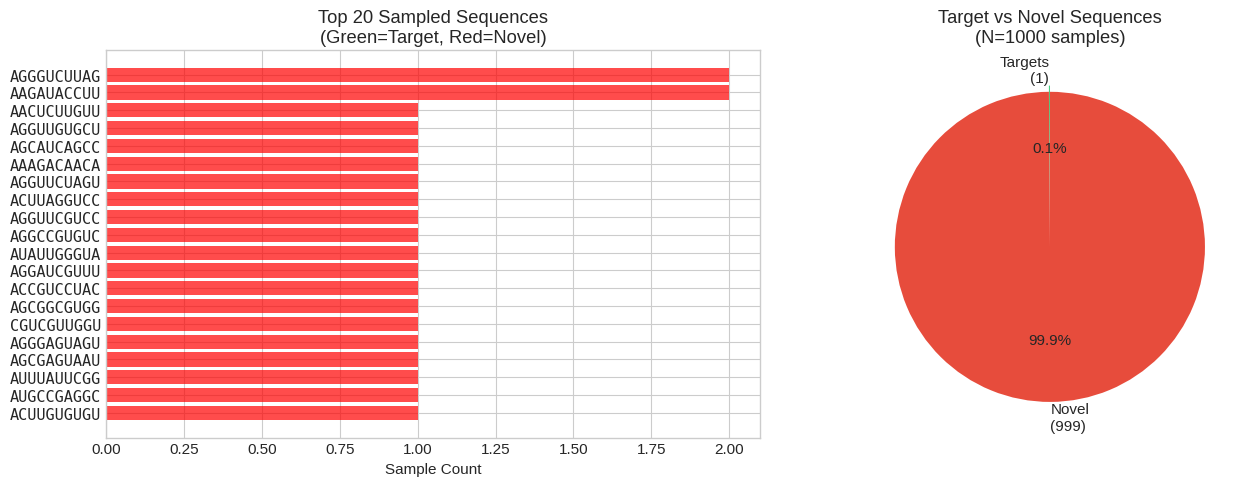

Saved to: results/sequence_design_distribution.pdf


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
top_seqs = sample_counts.most_common(20)
seqs = [s[0] for s in top_seqs]
counts = [s[1] for s in top_seqs]
colors = ['green' if s in target_seqs else 'red' for s in seqs]

bars = ax1.barh(range(len(seqs)), counts, color=colors, alpha=0.7)
ax1.set_yticks(range(len(seqs)))
ax1.set_yticklabels(seqs, fontfamily='monospace')
ax1.set_xlabel('Sample Count')
ax1.set_title('Top 20 Sampled Sequences\n(Green=Target, Red=Novel)')
ax1.invert_yaxis()

if greedy_seq in seqs:
    idx = seqs.index(greedy_seq)
    ax1.barh(idx, counts[idx], color='gold', alpha=0.9, edgecolor='black', linewidth=2)
    ax1.annotate('GREEDY', xy=(counts[idx], idx), xytext=(5, 0), 
                textcoords='offset points', fontweight='bold')

ax2 = axes[1]
target_count = sum(1 for s in sampled_seqs if s in target_seqs)
novel_count = N_SAMPLES - target_count

ax2.pie([target_count, novel_count], 
        labels=[f'Targets\n({target_count})', f'Novel\n({novel_count})'],
        colors=['#2ecc71', '#e74c3c'],
        autopct='%1.1f%%',
        startangle=90,
        explode=(0.02, 0.02))
ax2.set_title(f'Target vs Novel Sequences\n(N={N_SAMPLES} samples)')

plt.tight_layout()
plt.savefig('results/sequence_design_distribution.pdf', bbox_inches='tight', dpi=150)
plt.show()
print("Saved to: results/sequence_design_distribution.pdf")

In [11]:
print(f"{'Method':<20} {'Result':>40}")
print("-" * 60)
print(f"{'Greedy:':<20} {greedy_seq:>40}")
print(f"{'  Is Target:':<20} {'Yes' if greedy_seq in target_seqs else 'No':>40}")
if greedy_seq in target_seqs:
    print(f"{'  Target Freq:':<20} {seq_counts.get(greedy_seq, 0):>40}")
    
print(f"\n{'Stochastic:':<20}")
print(f"{'  Unique Seqs:':<20} {len(sample_counts):>40}")
print(f"{'  Target Hit Rate:':<20} {target_hits/N_SAMPLES*100:.1f}%{' ':>32}")
print(f"{'  Unique Targets:':<20} {unique_targets_hit}/{len(target_seqs)}{' ':>30}")
print(f"{'  Novel Seqs:':<20} {len(novel_seqs):>40}")

most_common_seq, most_common_count = sample_counts.most_common(1)[0]
print(f"\n{'Most Common:':<20} {most_common_seq:>40}")
print(f"{'  Count:':<20} {most_common_count} ({most_common_count/N_SAMPLES*100:.1f}%){' ':>20}")
print(f"{'  Same as Greedy:':<20} {'Yes' if most_common_seq == greedy_seq else 'No':>40}")

Method                                                 Result
------------------------------------------------------------
Greedy:                                            AGGUUUUAUC
  Is Target:                                               No

Stochastic:         
  Unique Seqs:                                            998
  Target Hit Rate:   0.1%                                
  Unique Targets:    1/58                              
  Novel Seqs:                                             997

Most Common:                                       AGGGUCUUAG
  Count:             2 (0.2%)                    
  Same as Greedy:                                          No


## Top-K Beam Search

In [12]:
def beam_search(model, k=10, insert_only=False):
    """Find top-k sequences by keeping k best partial sequences at each step."""
    config = get_env_config()
    
    beam = [(get_initial_state(), 0.0)]
    
    for step in range(config.max_seq_len):
        candidates = []
        
        for state, log_prob in beam:
            probs = get_policy_probs(model, state, insert_only=insert_only)
            mask = calculate_forward_mask(state[1], insert_only=insert_only)
            valid_actions = torch.where(mask)[0]
            
            for action_idx in valid_actions:
                action_idx = action_idx.item()
                action_prob = probs[action_idx].item()
                if action_prob > 0:
                    new_state = perform_action(state, action_idx)
                    new_log_prob = log_prob + np.log(action_prob + 1e-10)
                    candidates.append((new_state, new_log_prob))
        
        candidates.sort(key=lambda x: -x[1])
        beam = candidates[:k]
    
    results = [(state_to_string(state), log_prob) for state, log_prob in beam]
    return results

K = 20
print(f"Running beam search with k={K}...")
top_k_seqs = beam_search(model, k=K, insert_only=INSERT_ONLY)

print(f"\nTop-{K} sequences:")
print(f"{'Rank':<6} {'Sequence':<12} {'Log Prob':>10} {'Is Target':>10} {'Target Freq':>12}")
print("-" * 55)
for i, (seq, log_prob) in enumerate(top_k_seqs):
    is_target = seq in target_seqs
    freq = seq_counts.get(seq, '-') if is_target else '-'
    print(f"{i+1:<6} {seq:<12} {log_prob:>10.2f} {'Yes' if is_target else 'No':>10} {freq:>12}")

Running beam search with k=20...

Top-20 sequences:
Rank   Sequence       Log Prob  Is Target  Target Freq
-------------------------------------------------------
1      AGGUUGUAUC       -19.85         No            -
2      AGGUUGUAUU       -19.96        Yes            2
3      AGGUUGUAUA       -20.02        Yes          208
4      AGGUUGUAGC       -20.04         No            -
5      AGGUUGUAGA       -20.10         No            -
6      AGGUUGUAUG       -20.10        Yes           53
7      AGGUUGUAGU       -20.18         No            -
8      AGGUUGUAAC       -20.23         No            -
9      AGGUUGUAAU       -20.32         No            -
10     AGGUUGUAAA       -20.36        Yes            2
11     AGGUUGUAGG       -20.38         No            -
12     AGGUUGAAUC       -20.38         No            -
13     AGGUUUUAUC       -20.39         No            -
14     AGGUUGAAGC       -20.40         No            -
15     AGGUUGUAGU       -20.40         No            -
16     AGGUU

## Beam Search Trajectory DAG

In [13]:
import networkx as nx
from collections import defaultdict

def beam_search_with_trajectories(model, k=10, insert_only=False):
    """Beam search that also tracks trajectories for DAG visualization."""
    config = get_env_config()
    
    initial_state = get_initial_state()
    beam = [(initial_state, 0.0, [])]
    
    for step in range(config.max_seq_len):
        candidates = []
        
        for state, log_prob, trajectory in beam:
            probs = get_policy_probs(model, state, insert_only=insert_only)
            mask = calculate_forward_mask(state[1], insert_only=insert_only)
            valid_actions = torch.where(mask)[0]
            
            current_state_str = state_to_string(state)
            
            for action_idx in valid_actions:
                action_idx = action_idx.item()
                action_prob = probs[action_idx].item()
                if action_prob > 0:
                    new_state = perform_action(state, action_idx)
                    new_log_prob = log_prob + np.log(action_prob + 1e-10)
                    
                    action = gfn_env.ACTIONS_LIST[action_idx]
                    new_trajectory = trajectory + [(current_state_str, action, action_idx)]
                    
                    candidates.append((new_state, new_log_prob, new_trajectory))
        
        candidates.sort(key=lambda x: -x[1])
        beam = candidates[:k]
    
    results = []
    for state, log_prob, trajectory in beam:
        final_seq = state_to_string(state)
        trajectory_complete = trajectory + [(final_seq, None, None)]
        results.append((final_seq, log_prob, trajectory_complete))
    
    return results


def build_beam_trajectory_dag(beam_results, target_seqs=None):
    """Build a DAG from beam search trajectories."""
    G = nx.DiGraph()
    edge_counts = defaultdict(int)
    node_visits = defaultdict(int)
    node_log_probs = defaultdict(list)
    
    for seq, log_prob, trajectory in beam_results:
        prev_state_str = ""
        
        for i, (state_str, action, action_idx) in enumerate(trajectory):
            node_visits[state_str] += 1
            
            if prev_state_str != state_str:
                edge_counts[(prev_state_str, state_str)] += 1
            
            if action is not None:
                node_log_probs[state_str].append(log_prob)
            
            prev_state_str = state_str
    
    for (src, dst), count in edge_counts.items():
        G.add_edge(src, dst, weight=count)
    
    for node in G.nodes():
        clean_seq = node.replace('ε', '') if node else ''
        G.nodes[node]['seq_len'] = len(clean_seq)
        G.nodes[node]['visits'] = node_visits[node]
        G.nodes[node]['is_target'] = clean_seq in target_seqs if target_seqs else False
        if node_log_probs[node]:
            G.nodes[node]['avg_log_prob'] = np.mean(node_log_probs[node])
    
    return G, dict(node_visits)


K = 20
print(f"Running beam search with k={K} (tracking trajectories)...")
beam_results = beam_search_with_trajectories(model, k=K, insert_only=INSERT_ONLY)

print(f"\nTop-{K} sequences:")
for i, (seq, log_prob, traj) in enumerate(beam_results[:10]):
    is_target = seq in target_seqs
    print(f"  {i+1}. {seq} (log_p={log_prob:.2f}, target={is_target})")

G_beam, node_visits_beam = build_beam_trajectory_dag(beam_results, target_seqs)
print(f"\nDAG: {G_beam.number_of_nodes()} nodes, {G_beam.number_of_edges()} edges")

Running beam search with k=20 (tracking trajectories)...

Top-20 sequences:
  1. AGGUUGUAUC (log_p=-19.85, target=False)
  2. AGGUUGUAUU (log_p=-19.96, target=True)
  3. AGGUUGUAUA (log_p=-20.02, target=True)
  4. AGGUUGUAGC (log_p=-20.04, target=False)
  5. AGGUUGUAGA (log_p=-20.10, target=False)
  6. AGGUUGUAUG (log_p=-20.10, target=True)
  7. AGGUUGUAGU (log_p=-20.18, target=False)
  8. AGGUUGUAAC (log_p=-20.23, target=False)
  9. AGGUUGUAAU (log_p=-20.32, target=False)
  10. AGGUUGUAAA (log_p=-20.36, target=True)

DAG: 35 nodes, 39 edges


Saved to: results/beam_search_trajectory_dag.pdf


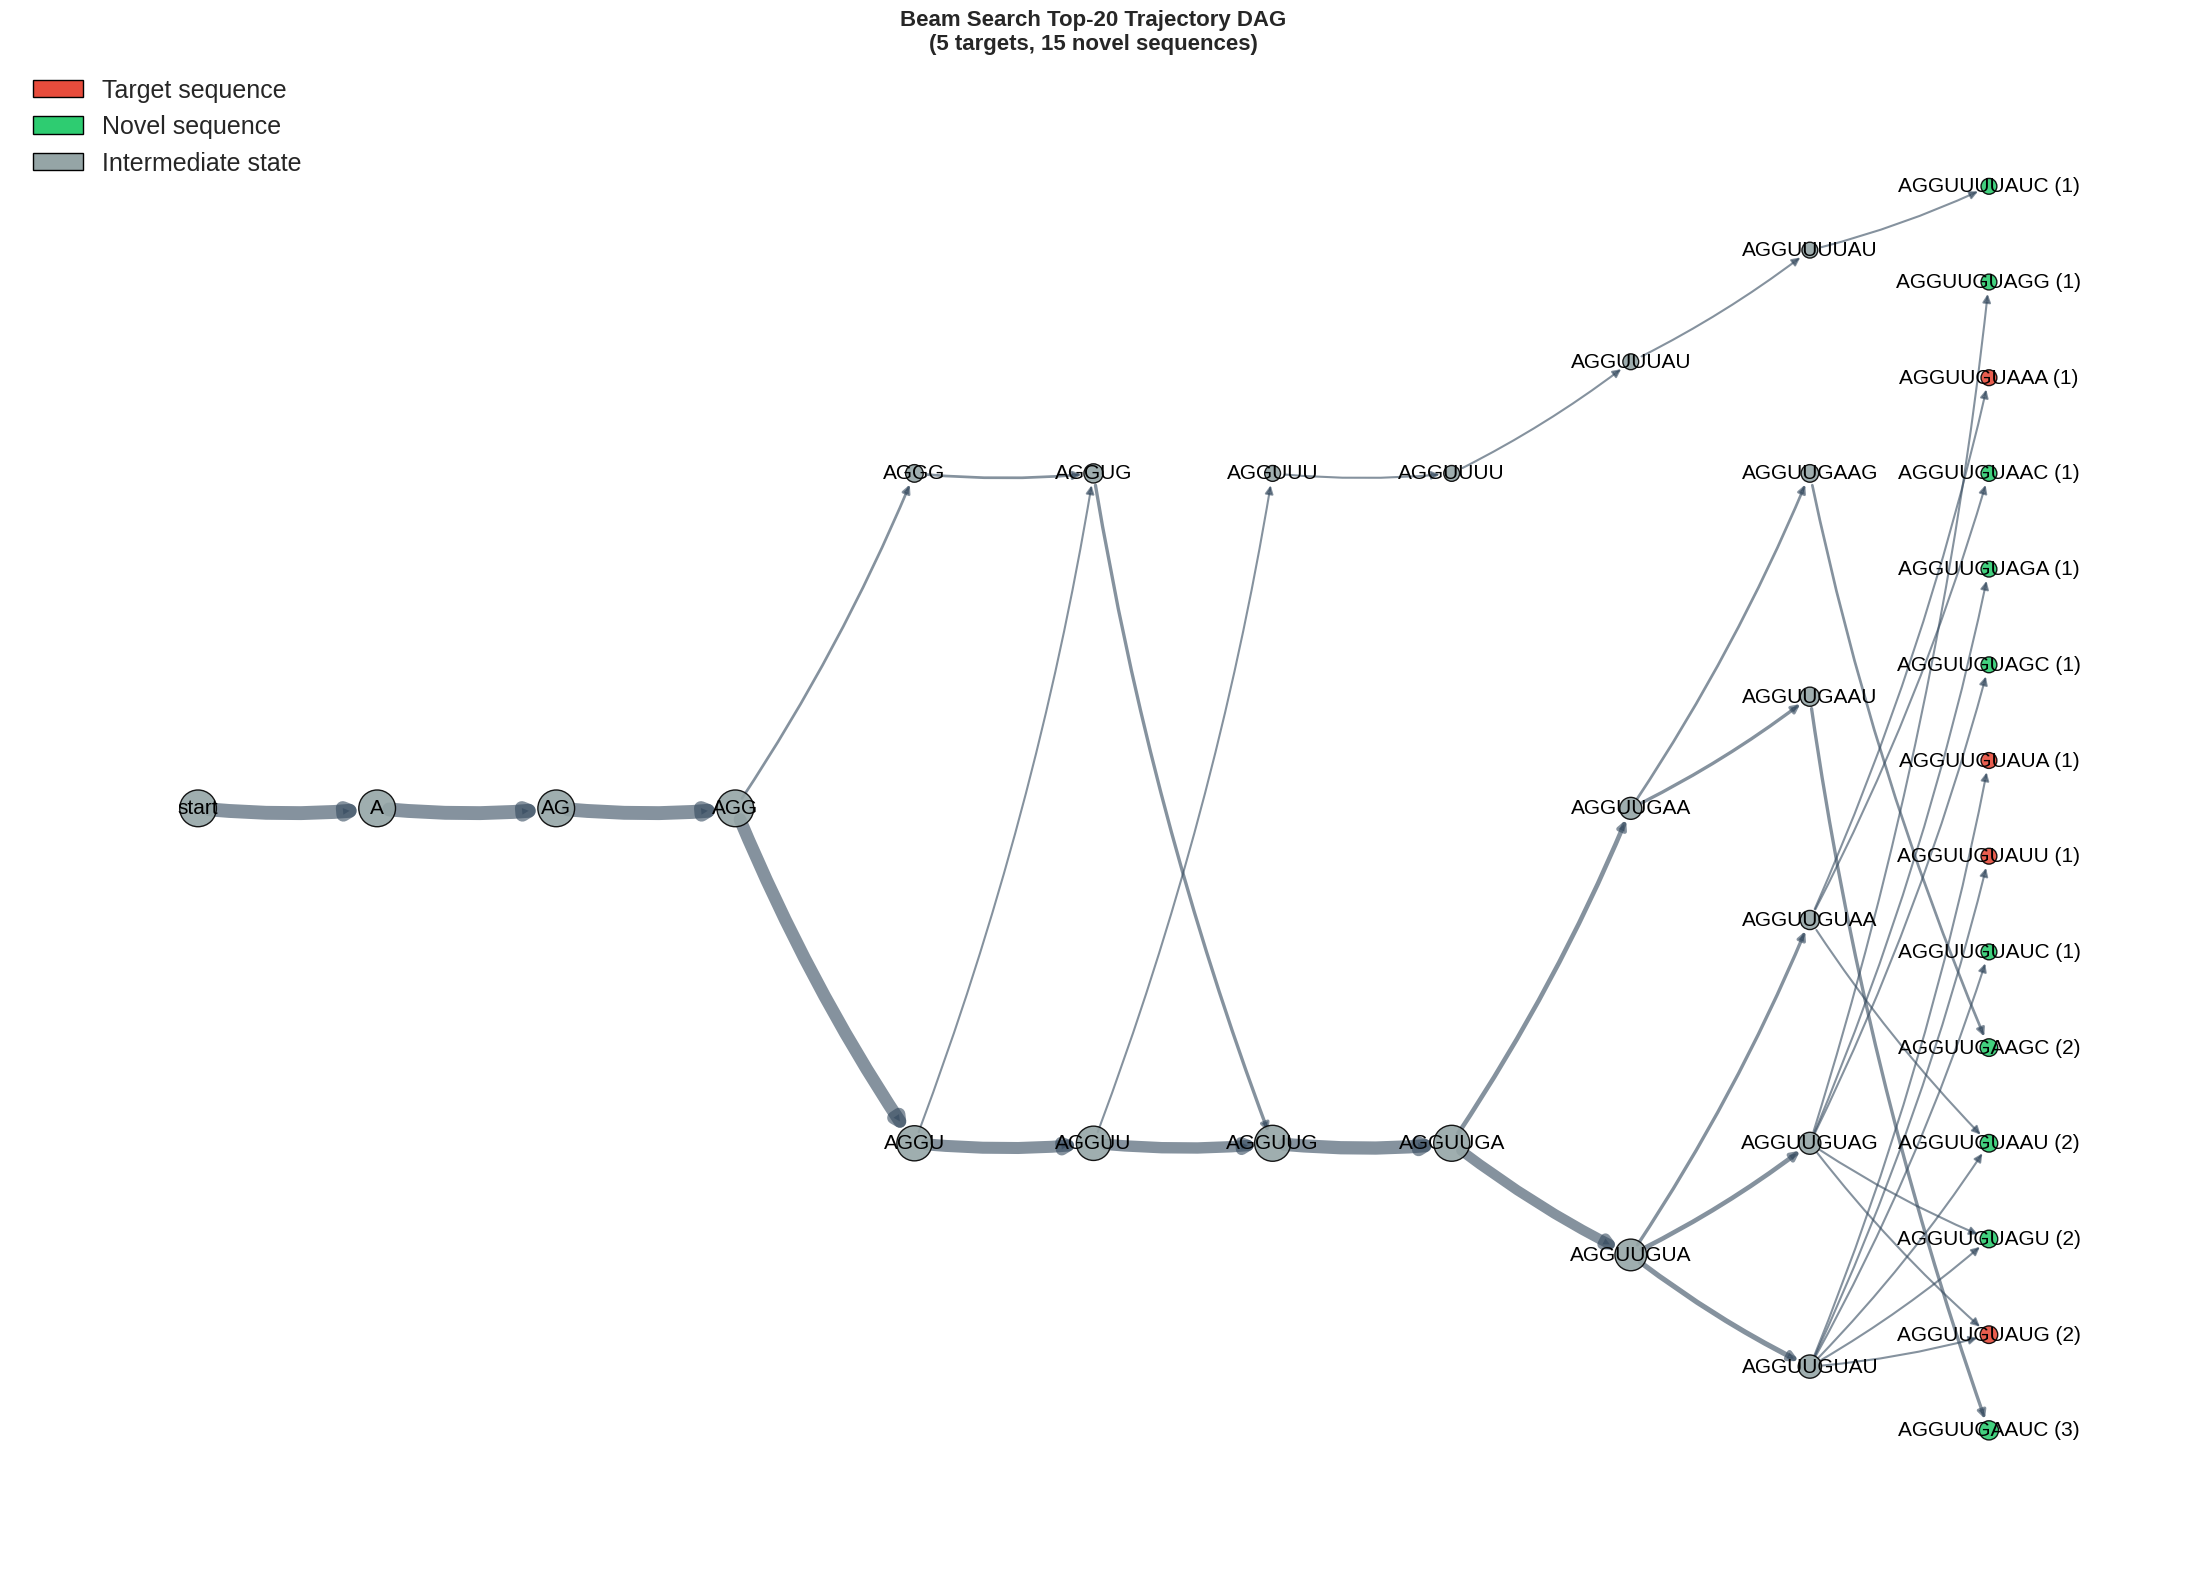

In [14]:
def plot_beam_trajectory_dag(G: nx.DiGraph, node_visits: Dict[str, int], 
                              target_seqs: set = None,
                              beam_results: list = None,
                              figsize=(20, 14),
                              min_edge_width: float = 1.0, 
                              max_edge_width: float = 8.0):
    """Plot the beam search trajectory DAG with hierarchical layout."""
    if G.number_of_nodes() == 0:
        print("Empty graph, nothing to plot.")
        return None
    
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.set_facecolor('white')
    ax.grid(False)
    ax.axis('off')
    
    layers = defaultdict(list)
    for node in G.nodes():
        seq_len = G.nodes[node].get('seq_len', 0)
        layers[seq_len].append(node)
    
    max_layer_idx = max(layers.keys()) if layers else 0
    
    pos = {}
    max_layer_size = max(len(nodes) for nodes in layers.values()) if layers else 1
    
    for layer_idx, nodes in sorted(layers.items()):
        n_nodes = len(nodes)
        nodes_sorted = sorted(nodes, key=lambda x: -node_visits.get(x, 0))
        
        for i, node in enumerate(nodes_sorted):
            x = layer_idx
            y = (i - (n_nodes - 1) / 2) * (max_layer_size / max(n_nodes, 1)) * 0.6
            pos[node] = (x, y)
    
    edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
    if edge_weights:
        max_weight = max(edge_weights)
        min_weight = min(edge_weights)
        weight_range = max_weight - min_weight if max_weight > min_weight else 1
        edge_widths = [
            min_edge_width + (w - min_weight) / weight_range * (max_edge_width - min_edge_width)
            for w in edge_weights
        ]
    else:
        edge_widths = [1]
    
    node_colors = []
    for node in G.nodes():
        seq_len = G.nodes[node].get('seq_len', 0)
        clean_seq = node.replace('ε', '') if node else ''
        
        if seq_len == max_layer_idx and clean_seq:
            if target_seqs and clean_seq in target_seqs:
                node_colors.append('#e74c3c')
            else:
                node_colors.append('#2ecc71')
        else:
            node_colors.append('#95a5a6')
    
    node_sizes = [100 + node_visits.get(node, 1) * 30 for node in G.nodes()]
    
    nx.draw_networkx_edges(
        G, pos, ax=ax,
        width=edge_widths,
        alpha=0.6,
        edge_color='#34495e',
        arrows=True,
        arrowsize=12,
        connectionstyle="arc3,rad=0.05"
    )
    
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_size=node_sizes,
        node_color=node_colors,
        alpha=0.9,
        edgecolors='black',
        linewidths=1
    )
    
    labels = {}
    for node in G.nodes():
        clean_seq = node.replace('ε', '') if node else ''
        seq_len = G.nodes[node].get('seq_len', 0)
        
        if seq_len == max_layer_idx and clean_seq:
            visits = node_visits.get(node, 0)
            labels[node] = f"{clean_seq} ({visits})"
        elif clean_seq:
            labels[node] = clean_seq
        else:
            labels[node] = "start"
    
    nx.draw_networkx_labels(
        G, pos, labels, ax=ax,
        font_size=15,
        font_weight='normal'
    )
    
    n_targets = sum(1 for seq, _, _ in beam_results if seq in target_seqs) if beam_results and target_seqs else 0
    fig.suptitle(
        f'Beam Search Top-{len(beam_results)} Trajectory DAG\n'
        f'({n_targets} targets, {len(beam_results)-n_targets} novel sequences)',
        fontsize=16, fontweight='bold', y=0.98
    )
    
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#e74c3c', edgecolor='black', label='Target sequence'),
        Patch(facecolor='#2ecc71', edgecolor='black', label='Novel sequence'),
        Patch(facecolor='#95a5a6', edgecolor='black', label='Intermediate state'),
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=18)
    
    plt.tight_layout()
    return fig


if 'G_beam' in dir() and G_beam is not None:
    fig_beam = plot_beam_trajectory_dag(
        G_beam, node_visits_beam, 
        target_seqs=target_seqs,
        beam_results=beam_results,
        figsize=(22, 16),
        min_edge_width=1.5,
        max_edge_width=10
    )
    
    if fig_beam:
        output_path = 'results/beam_search_trajectory_dag.pdf'
        fig_beam.savefig(output_path, format='pdf', bbox_inches='tight', dpi=150)
        print(f"Saved to: {output_path}")
        plt.show()

In [15]:
def print_beam_trajectory(seq, log_prob, trajectory, target_seqs=None):
    """Print step-by-step trajectory for a beam search result."""
    is_target = seq in target_seqs if target_seqs else False
    status = "TARGET" if is_target else "NOVEL"
    
    print(f"\nSequence: {seq}  [{status}]")
    print(f"Log Probability: {log_prob:.4f}")
    
    print(f"\n{'Step':<5} {'State':<12} {'Action':<25}")
    print("-" * 45)
    
    for i, (state_str, action, action_idx) in enumerate(trajectory):
        if action is not None:
            action_type, pos, char = action
            action_str = f"{action_type} '{char}' at pos {pos}"
        else:
            action_str = "(terminal)"
        
        display_state = state_str if state_str else "(empty)"
        print(f"{i:<5} {display_state:<12} {action_str:<25}")

for i, (seq, log_prob, traj) in enumerate(beam_results[:5]):
    print_beam_trajectory(seq, log_prob, traj, target_seqs)


Sequence: AGGUUGUAUC  [NOVEL]
Log Probability: -19.8489

Step  State        Action                   
---------------------------------------------
0     (empty)      insert 'A' at pos 0      
1     A            insert 'G' at pos 1      
2     AG           insert 'G' at pos 1      
3     AGG          insert 'U' at pos 3      
4     AGGU         insert 'U' at pos 3      
5     AGGUU        insert 'G' at pos 5      
6     AGGUUG       insert 'A' at pos 6      
7     AGGUUGA      insert 'U' at pos 6      
8     AGGUUGUA     insert 'U' at pos 8      
9     AGGUUGUAU    insert 'C' at pos 9      
10    AGGUUGUAUC   (terminal)               

Sequence: AGGUUGUAUU  [TARGET]
Log Probability: -19.9639

Step  State        Action                   
---------------------------------------------
0     (empty)      insert 'A' at pos 0      
1     A            insert 'G' at pos 1      
2     AG           insert 'G' at pos 1      
3     AGG          insert 'U' at pos 3      
4     AGGU         insert 

In [16]:
def analyze_trajectory_divergence(beam_results, target_seqs):
    """Find where target and non-target trajectories diverge."""
    target_trajs = [(seq, lp, traj) for seq, lp, traj in beam_results if seq in target_seqs]
    novel_trajs = [(seq, lp, traj) for seq, lp, traj in beam_results if seq not in target_seqs]
    
    print(f"Targets in top-{len(beam_results)}: {len(target_trajs)}")
    print(f"Novel in top-{len(beam_results)}: {len(novel_trajs)}")
    
    if target_trajs and novel_trajs:
        best_target = target_trajs[0]
        best_novel = novel_trajs[0]
        
        print(f"\nBest target: {best_target[0]} (log_p={best_target[1]:.2f})")
        print(f"Best novel:  {best_novel[0]} (log_p={best_novel[1]:.2f})")
        
        target_states = [s for s, _, _ in best_target[2]]
        novel_states = [s for s, _, _ in best_novel[2]]
        
        diverge_step = 0
        for i, (ts, ns) in enumerate(zip(target_states, novel_states)):
            if ts != ns:
                diverge_step = i
                break
            diverge_step = i + 1
        
        print(f"\nDivergence point: Step {diverge_step}")
        if diverge_step > 0:
            print(f"  Common prefix: '{target_states[diverge_step-1]}'")
        if diverge_step < len(target_states):
            print(f"  Target continues: '{target_states[diverge_step]}'")
        if diverge_step < len(novel_states):
            print(f"  Novel continues:  '{novel_states[diverge_step]}'")
    
    # Last character choices
    print(f"\nFinal position choices:")
    for seq, lp, traj in beam_results[:10]:
        is_target = "T" if seq in target_seqs else " "
        if len(traj) >= 2:
            _, last_action, _ = traj[-2]
            if last_action:
                _, pos, char = last_action
                print(f"  {seq}: pos={pos}, char='{char}' [{is_target}]")


analyze_trajectory_divergence(beam_results, target_seqs)

Targets in top-20: 5
Novel in top-20: 15

Best target: AGGUUGUAUU (log_p=-19.96)
Best novel:  AGGUUGUAUC (log_p=-19.85)

Divergence point: Step 10
  Common prefix: 'AGGUUGUAU'
  Target continues: 'AGGUUGUAUU'
  Novel continues:  'AGGUUGUAUC'

Final position choices:
  AGGUUGUAUC: pos=9, char='C' [ ]
  AGGUUGUAUU: pos=9, char='U' [T]
  AGGUUGUAUA: pos=9, char='A' [T]
  AGGUUGUAGC: pos=9, char='C' [ ]
  AGGUUGUAGA: pos=9, char='A' [ ]
  AGGUUGUAUG: pos=9, char='G' [T]
  AGGUUGUAGU: pos=9, char='U' [ ]
  AGGUUGUAAC: pos=9, char='C' [ ]
  AGGUUGUAAU: pos=9, char='U' [ ]
  AGGUUGUAAA: pos=9, char='A' [T]


## Save Results

In [17]:
# Save analysis results
results = {
    'greedy_sequence': greedy_seq,
    'greedy_is_target': greedy_seq in target_seqs,
    'greedy_trajectory': greedy_traj,
    'stochastic_samples': dict(sample_counts),
    'n_samples': N_SAMPLES,
    'target_hit_rate': target_hits / N_SAMPLES,
    'unique_targets_hit': unique_targets_hit,
    'novel_sequences': dict(novel_seqs),
    'top_k_beam_search': top_k_seqs,
}

output_path = 'results/sequence_design_analysis.json'
with open(output_path, 'w') as f:
    json.dump(results, f, indent=2, default=str)

print(f"Results saved to: {output_path}")

Results saved to: results/sequence_design_analysis.json
